<a href="https://colab.research.google.com/github/Megapietia/Dark/blob/main/Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [2]:
import pandas as pd
import numpy as np
import scipy.stats
import pandas_datareader as reader
import datetime as dt
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


# **Experiments**

In [ ]:
df = pd.read_csv('4SBER.csv', usecols=['Дата','Цена', 'Изм. %'], engine='python')
# цена
cost = np.array(df['Цена'], dtype=str)
cost = np.char.replace(cost, ',', '.').astype(np.float32)
# доходность
change = np.array(df['Изм. %'], dtype='<U6')
change = np.char.replace(change, '%', '')
change = np.char.replace(change, ',', '.').astype(np.float32)
# дата
date = np.array(df['Дата'], dtype=str)
# итоговый датафрейм
findf = pd.DataFrame([date, cost, change])
findf = findf.transpose().rename(columns={0: 'Date',1: 'Cost', 2: 'Change'}).iloc[::-1]
findf
# Статистика
stats = pd.DataFrame([cost, change])
stats = stats.transpose().rename(columns={0: 'Cost', 1: 'Change'})
stats
# График
# findf.plot('Date', 'Cost')



FileNotFoundError: ignored

In [ ]:
SberStdCost = stats.std()[0]
SberStdChange = stats.std()[1]
SberMeanCost = stats.mean()[0]
SberMeanChange = stats.mean()[1]

NameError: ignored

In [ ]:
SberStdCost

In [ ]:
SberMeanCost

In [ ]:
stats.describe()

In [ ]:
def VaRWiki(Position, mu, sigma, Quantile, Period):
  return Position*(-mu*Period+scipy.stats.norm.ppf(Quantile)*sigma*(Period)**(1/2))
  

In [ ]:
VaRWiki(stats['Cost'].iloc[-1], SberMeanChange,SberStdChange, 0.95, 7/365)

# **Calculation VaR for portfolio**

In [ ]:
def VaR(Position,sigma,Quantile):
  return Position*sigma*scipy.stats.norm.ppf(Quantile)

In [ ]:
end = dt.datetime.now()
start = dt.datetime(end.year-4, end.month, end.day)

In [ ]:
period = ((end - start).days)/365
Quantile = 0.95

In [ ]:
df = reader.get_data_yahoo(['AAPL','MSFT','TSLA'], start, end)['Adj Close']

In [ ]:
returns = np.log(1+df.pct_change())

In [ ]:
returns.std()

Symbols
AAPL    0.020282
MSFT    0.018407
TSLA    0.039375
dtype: float64

In [ ]:
Position = df.iloc[-1]

In [ ]:
VaRarray = []
for i in range(len(Position)):
  VaRarray.append(VaR(Position[i], returns.std()[i], Quantile))

In [ ]:
VaRarray

[4.214670089324679, 7.1334632113992695, 45.35594595264133]

In [ ]:
vector = np.array(VaRarray)

In [ ]:
returns.corr()

Symbols,AAPL,MSFT,TSLA
Symbols,,,
AAPL,1.000000,0.752040,0.422317
MSFT,0.752040,1.000000,0.438527
TSLA,0.422317,0.438527,1.000000


In [ ]:
print(f"С вероятностью {Quantile} величина убытков портфеля не превысит {(np.dot(np.dot(vector, returns.corr()),vector))**(1/2)} долларов в течение {period} лет")

С вероятностью 0.95 величина убытков портфеля не превысит 51.14938274882958 долларов в течение 4.002739726027397 лет


# **Calculating beta,alpha and creating regression model(Sharp model)**

In [21]:
end = dt.datetime.now()
start = dt.date(end.year - 1, end.month,end.day)
Input = ['TSLA', '^GSPC']

In [22]:
df = reader.get_data_yahoo(Input, start, end)['Adj Close']
df.head()

Symbols,TSLA,^GSPC
Date,,
2020-03-05,144.908005,3023.939941
2020-03-06,140.695999,2972.370117
2020-03-09,121.599998,2746.560059
2020-03-10,129.065994,2882.229980
2020-03-11,126.846001,2741.379883


In [23]:
dl_ret = df.resample('M').ffill().pct_change()
dl_ret = dl_ret.dropna(axis=0)
dl_ret.head()

Symbols,TSLA,^GSPC
Date,,
2020-04-30,0.492137,0.126844
2020-05-31,0.067939,0.045282
2020-06-30,0.293186,0.018388
2020-07-31,0.325011,0.055101
2020-08-31,0.741452,0.070065


In [24]:
X =  dl_ret['^GSPC']
y = dl_ret['TSLA']
X_sm = sm.add_constant(X)

In [25]:
model = sm.OLS(y, X_sm)
results = model.fit()

In [26]:
results.summary()

/usr/local/lib/python3.7/dist-packages/scipy/stats/stats.py:1535: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  "anyway, n=%i" % int(n))


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   TSLA   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     16.36
Date:                Fri, 05 Mar 2021   Prob (F-statistic):            0.00234
Time:                        15:46:06   Log-Likelihood:                 4.0674
No. Observations:                  12   AIC:                            -4.135
Df Residuals:                      10   BIC:                            -3.165
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0394      0.065      0.604      0.559      -0.106       0.185
^GSPC          4.4281      1.095      4.045      0.002       1.989       6.867
==============================================================================
Omnibus:                        1.986   Durbin-Watson:                   1.858
Prob(Omnibus):                  0.370   Jarque-Bera (JB):                0.552
Skew:                           0.509   Prob(JB):                        0.759
Kurtosis:                       3.258   Cond. No.                         20.1
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
alpha = results.params[0]
beta = results.params[1]
print(f'alpha: {alpha}, beta: {beta}')

alpha: 0.03944949794813607, beta: 4.428057867038923


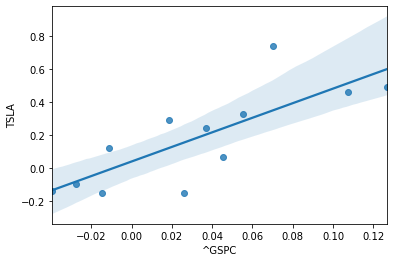

In [28]:
sns.regplot(x='^GSPC', y='TSLA', data=dl_ret)
plt.show()

# **Stock price simulation**

In [ ]:
days_ToPred = 252

In [ ]:
end = dt.datetime.now()
start = dt.datetime(end.year-5, end.month, end.day)

In [ ]:
df = reader.get_data_yahoo(['TSLA'], start, end)['Adj Close']
df.describe()

Symbols,TSLA
count,1259.000000
mean,126.691334
std,171.704331
min,35.793999
25%,49.282999
50%,62.716000
75%,74.900997
max,883.090027


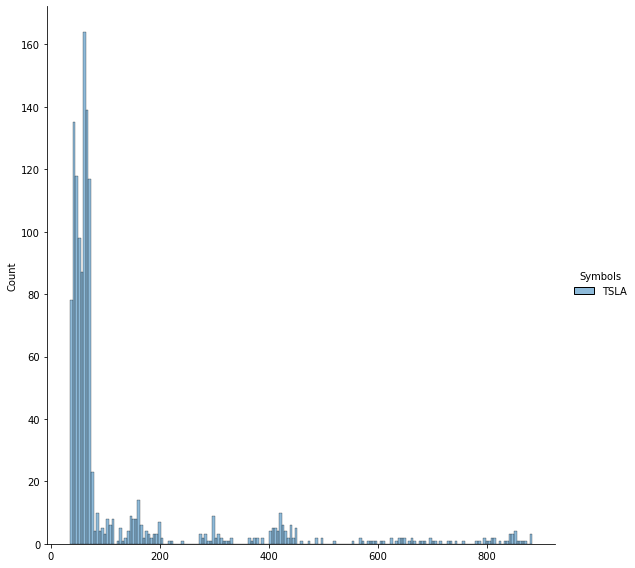

In [ ]:
sns.displot(df, height=8)

In [ ]:
returns = np.log(1+df.pct_change())
mu, sigma = returns.mean(), returns.std()


In [ ]:
sim_rets = np.random.normal(mu,sigma,days_ToPred)
initial = df.iloc[-1][0]

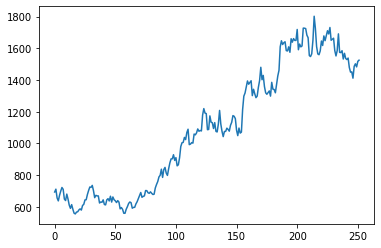

In [ ]:
sim_prices = initial * (sim_rets + 1).cumprod()
plt.plot(sim_prices)

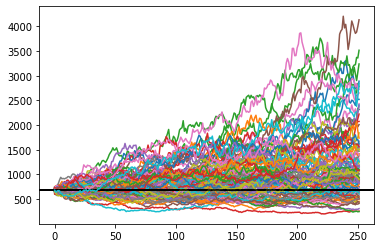

In [ ]:
for i in range(100):
  sim_rets = np.random.normal(mu,sigma,days_ToPred)
  sim_prices = initial * (sim_rets + 1).cumprod()
  plt.axhline(initial,c='k')
  plt.plot(sim_prices)

Text(0.5, 6.79999999999999, 'Price after 252 days')

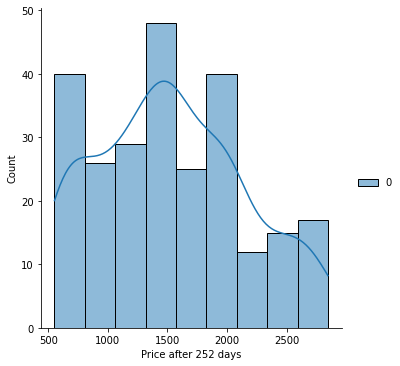

In [ ]:
sns.displot(pd.DataFrame(sim_prices), kde=True)
plt.xlabel(f"Price after {days_ToPred} days")


In [ ]:
pd.DataFrame(sim_prices).describe()

,0
count,252.000000
mean,1525.960082
std,615.091235
min,552.428016
25%,1029.238961
50%,1492.330794
75%,1969.137878
max,2845.729755


# **Stock price simulation 2**

In [3]:
end = dt.datetime.now()
start = dt.datetime(end.year-5, end.month, end.day)

In [4]:
data = pd.DataFrame(reader.get_data_yahoo(['TSLA'], start, end)['Adj Close'])
new_data = pd.DataFrame(reader.get_data_yahoo(['TSLA'], start, end)['Adj Close'])

In [5]:
last_price = round(new_data.iloc[-1].values[0], 2)

In [6]:
def log_returns(data):
    return (np.log(1+data.pct_change()))

In [7]:
log_return = log_returns(data).dropna()

In [8]:
def simple_returns(data):
    return ((data/data.shift(1))-1).dropna()

In [9]:
def market_data_combination(data, mark_ticker = "^GSPC"):
    market_data = pd.DataFrame(pd.DataFrame(reader.get_data_yahoo("^GSPC", start, end)['Adj Close']).rename(columns={'Adj Close': '^GSPC'}))
    market_rets = log_returns(market_data).dropna()
    ann_return = np.exp(market_rets.mean()*252).values-1
    data = data.merge(market_data, left_index=True, right_index=True)
    return data, ann_return

In [10]:
def beta_sharpe(data, mark_ticker="^GSPC", riskfree = 0.025):
    dd, mark_ret = market_data_combination(data)
    log_ret = log_returns(dd)
    covar = log_ret.cov()*252
    covar = pd.DataFrame(covar.iloc[:-1,-1])
    mrk_var = log_ret.iloc[:,-1].var()*252
    beta = covar/mrk_var
    
    stdev_ret = pd.DataFrame(((log_ret.std()*250**0.5)[:-1]), columns=['STD'])
    beta = beta.merge(stdev_ret, left_index=True, right_index=True)
    
    # CAPM
    for i, row in beta.iterrows():
        beta.at[i,'CAPM'] = riskfree + (row[mark_ticker] * (mark_ret-riskfree))
    # Sharpe
    for i, row in beta.iterrows():
        beta.at[i,'Sharpe'] = ((row['CAPM']-riskfree)/(row['STD']))
    beta.rename(columns={"^GSPC":"Beta"}, inplace=True)
    
    return beta

In [11]:
beta_sharpe(data)

,Beta,STD,CAPM,Sharpe
TSLA,1.310731,0.578307,0.169341,0.249593


In [12]:
def drift_calc(data, return_type='log'):
    if return_type=='log':
        lr = log_returns(data)
    elif return_type=='simple':
        lr = simple_returns(data)
    mu = lr.mean()
    var = lr.var()
    drift = mu-(0.5*var)
    try:
        return drift.values
    except:
        return drift

In [13]:
drift_calc(data)

array([0.00144057])

In [14]:
def daily_returns(data, days, iterations, return_type='log'):
    ft = drift_calc(data, return_type)
    if return_type == 'log':
        try:
            stv = log_returns(data).std().values
        except:
            stv = log_returns(data).std()
    elif return_type=='simple':
        try:
            stv = simple_returns(data).std().values
        except:
            stv = simple_returns(data).std()    
    dr = np.exp(ft + stv * scipy.stats.norm.ppf(np.random.rand(days, iterations)))
    return dr


In [15]:
dr = daily_returns(data, 2, 3)
dr

array([[1.05084246, 0.96922304, 0.95794662],
       [1.0217713 , 1.04370899, 0.9772902 ]])

In [16]:
def probs_find(predicted, higherthan, on = 'value'):
    if on == 'return':
        predicted0 = predicted.iloc[0,0]
        predicted = predicted.iloc[-1]
        predList = list(predicted)
        over = [(i*100)/predicted0 for i in predList if ((i-predicted0)*100)/predicted0 >= higherthan]
        less = [(i*100)/predicted0 for i in predList if ((i-predicted0)*100)/predicted0 < higherthan]
    elif on == 'value':
        predicted = predicted.iloc[-1]
        predList = list(predicted)
        over = [i for i in predList if i >= higherthan]
        less = [i for i in predList if i < higherthan]
    else:
        print("'on' must be either value or return")
    return (len(over)/(len(over)+len(less)))

In [19]:
def simulate_mc(data, days, iterations, return_type='log', plot=True):
    # Generate daily returns
    returns = daily_returns(data, days, iterations, return_type)
    # Create empty matrix
    price_list = np.zeros_like(returns)
    # Put the last actual price in the first row of matrix. 
    price_list[0] = data.iloc[-1]
    # Calculate the price of each day
    for t in range(1,days):
        price_list[t] = price_list[t-1]*returns[t]
    
    # Plot Option
    if plot == True:
        x = pd.DataFrame(price_list).iloc[-1]
        sns.displot(x, kde=True, aspect=2)
        plt.xlabel("Stock Price")
        plt.show()
    
    # Printing information about stock
    try:
        [print(nam) for nam in data.columns]
    except:
        print(data.name)
    print(f"Days: {days-1}")
    print(f"last price: ${last_price}")
    print(f"Expected Value: ${round(pd.DataFrame(price_list).iloc[-1].mean(),2)}")
    print(f"Return: {round(100*(pd.DataFrame(price_list).iloc[-1].mean()-price_list[0,1])/pd.DataFrame(price_list).iloc[-1].mean(),2)}%")
    print(f"Probability of Breakeven: {probs_find(pd.DataFrame(price_list),0, on='return')}")
    print(beta_sharpe(data).iloc[0].transpose().to_string())
    print(pd.DataFrame(price_list).iloc[-1].describe(percentiles=[.95, .99, .5]))
          
    return 

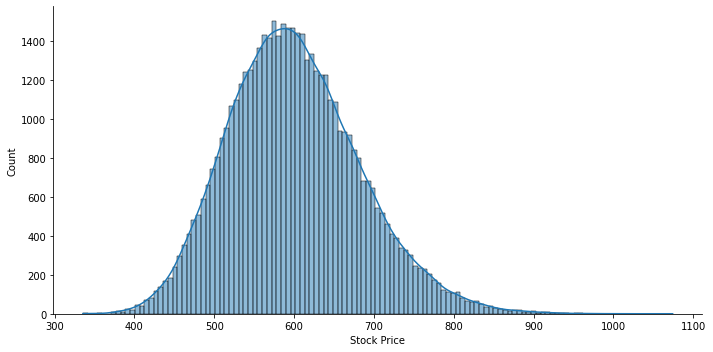

TSLA
Days: 14
last price: $582.86
Expected Value: $600.62
Return: 2.89%
Probability of Breakeven: 0.55966
Beta      1.310660
STD       0.578307
CAPM      0.169394
Sharpe    0.249683
count    50000.000000
mean       600.616399
std         82.335280
min        335.601638
50%        595.175929
95%        745.484422
99%        817.304355
max       1074.179502
Name: 14, dtype: float64


In [20]:
simulate_mc(data, 15, 50000, 'log')